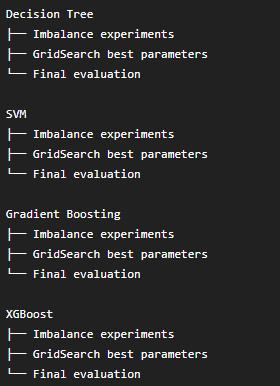

## Decision Tree

In [2]:
import pandas as pd 
import numpy as np 

In [5]:
X_train = pd.read_csv("../data/processed/split/X_train_scaled.csv")
X_test = pd.read_csv("../data/processed/split/X_test_scaled.csv")

y_train = pd.read_csv("../data/processed/split/y_train.csv")
y_test = pd.read_csv("../data/processed/split/y_test.csv")

In [7]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [8]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 9)
X_test: (2000, 9)
y_train: (8000,)
y_test: (2000,)


In [9]:
import mlflow
import mlflow.sklearn

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

In [10]:
mlflow.set_experiment("Predictive_Maintenance")

2026/09/05 12:49:03 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/05 12:49:03 INFO mlflow.store.db.utils: Updating database tables
2026/09/05 12:49:08 INFO mlflow.tracking.fluent: Experiment with name 'Predictive_Maintenance' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///e:/Predictive maintenance/experiments/mlruns/1', creation_time=1788592748455, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1788592748455, lifecycle_stage='active', name='Predictive_Maintenance', tags={}, trace_location=None, workspace='default'>

In [11]:
with mlflow.start_run(run_name="Decision_Tree_No_Balancing"):

    model = DecisionTreeClassifier(
        random_state=42
    )

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    )

    mlflow.log_param(
        "imbalance_strategy",
        "no_balancing"
    )

    mlflow.log_param(
        "model",
        "DecisionTreeClassifier"
    )

    mlflow.log_metric(
        "cv_f1_mean",
        cv_scores.mean()
    )

    mlflow.log_metric(
        "cv_f1_std",
        cv_scores.std()
    )

    print("CV F1 Mean:", cv_scores.mean())
    print("CV F1 Std:", cv_scores.std())

CV F1 Mean: 0.8139586072317119
CV F1 Std: 0.0194750750653863


In [12]:
with mlflow.start_run(run_name="Decision_Tree_Class_Weight"):

    model = DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    )

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    )

    mlflow.log_param(
        "imbalance_strategy",
        "class_weight"
    )

    mlflow.log_param(
        "model",
        "DecisionTreeClassifier"
    )

    mlflow.log_param(
        "class_weight",
        "balanced"
    )

    mlflow.log_metric(
        "cv_f1_mean",
        cv_scores.mean()
    )

    mlflow.log_metric(
        "cv_f1_std",
        cv_scores.std()
    )

    print("CV F1 Mean:", cv_scores.mean())
    print("CV F1 Std:", cv_scores.std())

CV F1 Mean: 0.7759518768693081
CV F1 Std: 0.016025353305917665


In [13]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [14]:
with mlflow.start_run(run_name="Decision_Tree_SMOTE"):

    pipeline = Pipeline([
        ("smote", SMOTE(random_state=42)),
        ("model", DecisionTreeClassifier(random_state=42))
    ])

    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    )

    mlflow.log_param(
        "imbalance_strategy",
        "SMOTE"
    )

    mlflow.log_param(
        "model",
        "DecisionTreeClassifier"
    )

    mlflow.log_metric(
        "cv_f1_mean",
        cv_scores.mean()
    )

    mlflow.log_metric(
        "cv_f1_std",
        cv_scores.std()
    )

    print("CV F1 Mean:", cv_scores.mean())
    print("CV F1 Std:", cv_scores.std())

CV F1 Mean: 0.6285313368152543
CV F1 Std: 0.02656697459178944


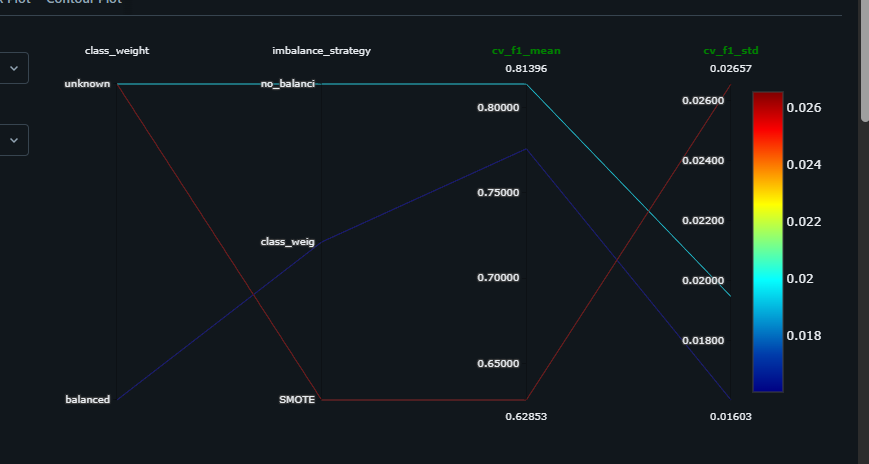

### For the Decision Tree, we should proceed with:

### No Balancing

In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

In [20]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

In [21]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [22]:
with mlflow.start_run(run_name="Decision_Tree_GridSearch"):

    grid_search = GridSearchCV(
        estimator=decision_tree,
        param_grid=param_grid,
        cv=5,
        scoring="f1",
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    # Log best parameters
    mlflow.log_params(grid_search.best_params_)

    # Log best CV score
    mlflow.log_metric(
        "best_cv_f1",
        grid_search.best_score_
    )

    print("Best Parameters:")
    print(grid_search.best_params_)

    print("\nBest CV F1 Score:")
    print(grid_search.best_score_)

Best Parameters:
{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best CV F1 Score:
0.8961848221787909


In [23]:
best_model = grid_search.best_estimator_

In [25]:
y_pred = best_model.predict(X_test)

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(
    y_test,
    best_model.predict_proba(X_test)[:, 1]
)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9925
Precision: 0.9491525423728814
Recall: 0.8235294117647058
F1 Score: 0.8818897637795275
ROC-AUC: 0.9420251796370722

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.95      0.82      0.88        68

    accuracy                           0.99      2000
   macro avg       0.97      0.91      0.94      2000
weighted avg       0.99      0.99      0.99      2000


Confusion Matrix:

[[1929    3]
 [  12   56]]


In [27]:
with mlflow.start_run(run_name="Decision_Tree_Final_Evaluation"):

    # Log best hyperparameters
    mlflow.log_params(grid_search.best_params_)

    # Log final test metrics
    mlflow.log_metric("test_accuracy", accuracy)
    mlflow.log_metric("test_precision", precision)
    mlflow.log_metric("test_recall", recall)
    mlflow.log_metric("test_f1", f1)
    mlflow.log_metric("test_roc_auc", roc_auc)

    # Log the trained best model
    mlflow.sklearn.log_model(
        sk_model=best_model,
        name="decision_tree_model"
    )

    print("Final Decision Tree evaluation logged to MLflow!")

2026/09/05 13:39:20 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Final Decision Tree evaluation logged to MLflow!


# SVM

In [28]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

with mlflow.start_run(run_name="SVM_No_Balancing"):

    model = SVC(
        random_state=42
    )

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    )

    mlflow.log_param("imbalance_strategy", "no_balancing")
    mlflow.log_param("model", "SVC")

    mlflow.log_metric("cv_f1_mean", cv_scores.mean())
    mlflow.log_metric("cv_f1_std", cv_scores.std())

    print("CV F1 Mean:", cv_scores.mean())
    print("CV F1 Std:", cv_scores.std())

CV F1 Mean: 0.5244816857989548
CV F1 Std: 0.054790865319264484


In [29]:
with mlflow.start_run(run_name="SVM_Class_Weight"):

    model = SVC(
        class_weight="balanced",
        random_state=42
    )

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    )

    mlflow.log_param("imbalance_strategy", "class_weight")
    mlflow.log_param("model", "SVC")
    mlflow.log_param("class_weight", "balanced")

    mlflow.log_metric("cv_f1_mean", cv_scores.mean())
    mlflow.log_metric("cv_f1_std", cv_scores.std())

    print("CV F1 Mean:", cv_scores.mean())
    print("CV F1 Std:", cv_scores.std())

CV F1 Mean: 0.4644565712972068
CV F1 Std: 0.02458919968538236


In [30]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

with mlflow.start_run(run_name="SVM_SMOTE"):

    pipeline = Pipeline([
        ("smote", SMOTE(random_state=42)),
        ("model", SVC(random_state=42))
    ])

    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    )

    mlflow.log_param("imbalance_strategy", "SMOTE")
    mlflow.log_param("model", "SVC")

    mlflow.log_metric("cv_f1_mean", cv_scores.mean())
    mlflow.log_metric("cv_f1_std", cv_scores.std())

    print("CV F1 Mean:", cv_scores.mean())
    print("CV F1 Std:", cv_scores.std())

CV F1 Mean: 0.47622518733743346
CV F1 Std: 0.03586134675306301


In [31]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

In [32]:
svm = SVC(
    random_state=42
)

param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

In [33]:
grid_search_svm = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search_svm.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search_svm.best_params_)

print("\nBest CV F1 Score:")
print(grid_search_svm.best_score_)

Best Parameters:
{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}

Best CV F1 Score:
0.7229646697388633


In [34]:
best_svm = grid_search_svm.best_estimator_

y_pred_svm = best_svm.predict(X_test)

y_prob_svm = best_svm.decision_function(X_test)

In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

roc_auc_svm = roc_auc_score(
    y_test,
    y_prob_svm
)

print("Accuracy:", accuracy_svm)
print("Precision:", precision_svm)
print("Recall:", recall_svm)
print("F1 Score:", f1_svm)
print("ROC-AUC:", roc_auc_svm)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_svm))

Accuracy: 0.9825
Precision: 0.8113207547169812
Recall: 0.6323529411764706
F1 Score: 0.7107438016528925
ROC-AUC: 0.9841599683351602

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.81      0.63      0.71        68

    accuracy                           0.98      2000
   macro avg       0.90      0.81      0.85      2000
weighted avg       0.98      0.98      0.98      2000


Confusion Matrix:

[[1922   10]
 [  25   43]]


In [36]:
with mlflow.start_run(run_name="SVM_Final_Evaluation"):

    # Log best hyperparameters
    mlflow.log_params(grid_search_svm.best_params_)

    # Log final test metrics
    mlflow.log_metric("test_accuracy", accuracy_svm)
    mlflow.log_metric("test_precision", precision_svm)
    mlflow.log_metric("test_recall", recall_svm)
    mlflow.log_metric("test_f1", f1_svm)
    mlflow.log_metric("test_roc_auc", roc_auc_svm)

    # Log the final trained model
    mlflow.sklearn.log_model(
        sk_model=best_svm,
        name="svm_model"
    )

    print("Final SVM evaluation logged to MLflow!")

2026/09/05 14:00:23 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Final SVM evaluation logged to MLflow!


In [37]:
# Gradient Boosting 

In [38]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

with mlflow.start_run(run_name="Gradient_Boosting_No_Balancing"):

    model = GradientBoostingClassifier(
        random_state=42
    )

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    )

    mlflow.log_param("imbalance_strategy", "no_balancing")
    mlflow.log_param("model", "GradientBoostingClassifier")

    mlflow.log_metric("cv_f1_mean", cv_scores.mean())
    mlflow.log_metric("cv_f1_std", cv_scores.std())

    print("CV F1 Mean:", cv_scores.mean())
    print("CV F1 Std:", cv_scores.std())

CV F1 Mean: 0.8862933976312254
CV F1 Std: 0.0189851897108216


In [39]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import StratifiedKFold
import numpy as np

# Create sample weights
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [41]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import GradientBoostingClassifier
import numpy as np

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = []

with mlflow.start_run(run_name="Gradient_Boosting_Sample_Weight"):

    for train_idx, val_idx in cv.split(X_train, y_train):

        # Split the training data for this fold
        X_train_fold = X_train.iloc[train_idx]
        X_val_fold = X_train.iloc[val_idx]

        y_train_fold = y_train.iloc[train_idx]
        y_val_fold = y_train.iloc[val_idx]

        # Calculate balanced weights ONLY for training fold
        sample_weights = compute_sample_weight(
            class_weight="balanced",
            y=y_train_fold
        )

        # Create model
        model = GradientBoostingClassifier(
            random_state=42
        )

        # Train with sample weights
        model.fit(
            X_train_fold,
            y_train_fold,
            sample_weight=sample_weights
        )

        # Validate
        y_pred = model.predict(X_val_fold)

        # Calculate F1
        fold_f1 = f1_score(
            y_val_fold,
            y_pred
        )

        cv_scores.append(fold_f1)

    # Log MLflow details
    mlflow.log_param("imbalance_strategy", "sample_weight")
    mlflow.log_param("model", "GradientBoostingClassifier")
    mlflow.log_metric("cv_f1_mean", np.mean(cv_scores))
    mlflow.log_metric("cv_f1_std", np.std(cv_scores))

    print("CV F1 Mean:", np.mean(cv_scores))
    print("CV F1 Std:", np.std(cv_scores))

CV F1 Mean: 0.6781290240885045
CV F1 Std: 0.028477537445539935


In [42]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

with mlflow.start_run(run_name="Gradient_Boosting_SMOTE"):

    pipeline = Pipeline([
        ("smote", SMOTE(random_state=42)),
        ("model", GradientBoostingClassifier(random_state=42))
    ])

    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    )

    mlflow.log_param("imbalance_strategy", "SMOTE")
    mlflow.log_param("model", "GradientBoostingClassifier")

    mlflow.log_metric("cv_f1_mean", cv_scores.mean())
    mlflow.log_metric("cv_f1_std", cv_scores.std())

    print("CV F1 Mean:", cv_scores.mean())
    print("CV F1 Std:", cv_scores.std())

CV F1 Mean: 0.5850645389958833
CV F1 Std: 0.041026039275234516


In [43]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

gradient_boosting = GradientBoostingClassifier(
    random_state=42
)

param_grid_gb = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 5],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [44]:
grid_search_gb = GridSearchCV(
    estimator=gradient_boosting,
    param_grid=param_grid_gb,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search_gb.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search_gb.best_params_)

print("\nBest CV F1 Score:")
print(grid_search_gb.best_score_)

Best Parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Best CV F1 Score:
0.8915159198834507


In [45]:
best_gb = grid_search_gb.best_estimator_

y_pred_gb = best_gb.predict(X_test)

y_prob_gb = best_gb.predict_proba(X_test)[:, 1]

In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)

roc_auc_gb = roc_auc_score(
    y_test,
    y_prob_gb
)

print("Accuracy:", accuracy_gb)
print("Precision:", precision_gb)
print("Recall:", recall_gb)
print("F1 Score:", f1_gb)
print("ROC-AUC:", roc_auc_gb)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_gb))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_gb))

Accuracy: 0.993
Precision: 1.0
Recall: 0.7941176470588235
F1 Score: 0.8852459016393442
ROC-AUC: 0.9663523017902813

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       1.00      0.79      0.89        68

    accuracy                           0.99      2000
   macro avg       1.00      0.90      0.94      2000
weighted avg       0.99      0.99      0.99      2000


Confusion Matrix:

[[1932    0]
 [  14   54]]


In [ ]:
with mlflow.start_run(run_name="Gradient_Boosting_Final_Evaluation"):

    # Log best hyperparameters
    mlflow.log_params(grid_search_gb.best_params_)

    # Log final test metrics
    mlflow.log_metric("test_accuracy", accuracy_gb)
    mlflow.log_metric("test_precision", precision_gb)
    mlflow.log_metric("test_recall", recall_gb)
    mlflow.log_metric("test_f1", f1_gb)
    mlflow.log_metric("test_roc_auc", roc_auc_gb)

    # Log the final trained model
    mlflow.sklearn.log_model(
        sk_model=best_gb,
        name="gradient_boosting_model"
    )

    print("Final Gradient Boosting ev-aluation logged to MLflow!")

2026/09/05 14:22:36 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Final Gradient Boosting evaluation logged to MLflow!
